## Kenya E-commerce & Delivery Performance Analytics

### Business Problem 

The e-commerce company lacks a clear understanding of how geographic location, courier performance, and delivery characteristics affect operational performance and customer experience.

### Data and analysis scope
The source contains 1,000 records and 14 original columns. The intended working grain is one record per order, but six repeated order IDs have conflicting details and remain unresolved. Results therefore use **order-record counts**, not verified unique-order counts.

This notebook documents exploratory findings. It does not establish causal explanations or recognized revenue.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("messy_kenya_ecommerce_large.csv")


In [4]:
data.head()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
0,KE-10001,CUST-5327,NaN,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35kg,353,6.0,Cancelled,3.0
1,KE-10002,CUST-5414,2025-01-04,kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0
2,KE-10003,CUST-5098,2025-12-27,Mombasa,Health & Wellness,3809.0,m-pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0
3,KE-10004,CUST-5138,2025-11-24,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,m-pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0


In [5]:
data.tail()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
995,KE-10996,CUST-5481,2025-12-24,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0
996,KE-10997,CUST-5481,2025-10-07,Nairobi,Health & Wellness,-17996,COD,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0
997,KE-10998,CUST-5387,2025-11-30,Mombasa,Electronics,10571.0,m-pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0
998,KE-10999,CUST-5037,2025-09-12,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0
999,KE-11000,CUST-5140,2025-08-18,Mombasa,Electronics,18015.0,M-Pesa,Home Delivery,DHL,29.31,228,5.0,Delivered,NaN


In [6]:
data.shape

(1000, 14)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            1000 non-null   object 
 1   Customer_ID         1000 non-null   object 
 2   Order_Date          964 non-null    object 
 3   Customer_County     972 non-null    object 
 4   Product_Category    1000 non-null   object 
 5   Order_Value_KES     971 non-null    object 
 6   Payment_Method      966 non-null    object 
 7   Delivery_Method     1000 non-null   object 
 8   Courier_Partner     1000 non-null   object 
 9   Package_Weight_Kg   1000 non-null   object 
 10  Shipping_Fee_KES    1000 non-null   int64  
 11  Transit_Time_Days   952 non-null    float64
 12  Fulfillment_Status  1000 non-null   object 
 13  Customer_Rating     848 non-null    float64
dtypes: float64(2), int64(1), object(11)
memory usage: 109.5+ KB


### Initial data inspection
Inspect sample records, data types, missingness, and category frequencies before transforming values. Whitespace is removed from text fields. Full-row duplicate checks are useful but must be complemented by checks of the intended identifier.

In [8]:
data = data.map(lambda x: x.strip() if isinstance(x, str) else x)


In [9]:
data[data.duplicated(keep= False)]


,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating


### Date parsing decision
Inspection found two structures: `YYYY-MM-DD` and `DD/MM/YYYY`. Parse each explicitly, then fill gaps in the first result with the second. Slash dates are interpreted as day/month/year based on examples such as `17/03/2025`; this is a working source-convention assumption.

Validation found no non-missing original dates that failed both conversion rules. Originally missing dates remain missing. Explicit parsing corrects the earlier month/day swaps and loss of valid dates. Successful parsing alone does not confirm the meaning of ambiguous dates.

In [10]:
data["Order_Date"].head(20
                    )

0            NaN
1     2025-01-04
2     2025-12-27
3     2025-11-24
4     2025-08-08
5     2025-10-02
6     2025-06-15
7     2025-10-04
8     2025-05-23
9     2025-04-09
10    2025-01-02
11    2025-04-06
12    2025-08-23
13    2025-03-01
14    2025-10-10
15    2025-07-28
16    2025-08-24
17    2025-11-02
18    2025-12-08
19    2025-03-28
Name: Order_Date, dtype: object

In [11]:
dates = data["Order_Date"].str.strip()
dates[dates.notna()  & ~dates.str.fullmatch(r"\d{4}-\d{2}-\d{2}", na=False)
]

20     17/03/2025
30     04/07/2025
67     15/03/2025
98     24/04/2025
198    24/08/2025
249    10/12/2025
326    01/08/2025
328    10/06/2025
422    10/02/2025
442    24/03/2025
508    31/08/2025
561    12/04/2025
668    07/10/2025
670    04/03/2025
759    23/12/2025
788    23/01/2025
980    13/12/2025
986    08/02/2025
Name: Order_Date, dtype: object

In [12]:
hyphen_dates = pd.to_datetime(
    dates,
    format="%Y-%m-%d",
    errors="coerce"
)

In [13]:
slash_dates = pd.to_datetime(
    dates,
    format="%d/%m/%Y",
    errors="coerce"
)

In [14]:
clean_dates = hyphen_dates.fillna(slash_dates) #keep converted hyphen date where missing use converted slash date


In [15]:
dates[dates.notna() & clean_dates.isna()]

Series([], Name: Order_Date, dtype: object)

In [16]:
data["Order_Date"] = clean_dates

In [17]:
data["Order_Date"].dtype


dtype('<M8[ns]')

In [18]:
data["Order_Date"].head()

0          NaT
1   2025-01-04
2   2025-12-27
3   2025-11-24
4   2025-08-08
Name: Order_Date, dtype: datetime64[ns]

### Category standardization
County capitalization is standardized, and `Nairobi County` is mapped to `Nairobi`. Payment aliases are consolidated to `M-Pesa` and `Cash on Delivery`. The spelling `Electrnics` is corrected to `Electronics`.

**Open item:** `Fashion` and `Fashion & Apparel` remain separate in the current transformation. No confirmation of whether they represent the same category before merging them.

In [19]:

data["Customer_County"].value_counts()



Customer_County
Mombasa           169
nairobi           101
kiambu             92
Machakos           85
Kajiado            82
Kiambu             78
Uasin Gishu        77
Nairobi County     76
Nairobi            76
Nakuru             71
Kisumu             65
Name: count, dtype: int64

In [20]:

data["Customer_County"] = data["Customer_County"].str.title()
data["Customer_County"] = data["Customer_County"].replace({'Nairobi County': 'Nairobi'
                                                          })


In [21]:

data["Customer_County"].value_counts()

Customer_County
Nairobi        253
Kiambu         170
Mombasa        169
Machakos        85
Kajiado         82
Uasin Gishu     77
Nakuru          71
Kisumu          65
Name: count, dtype: int64

In [22]:
data['Product_Category'].value_counts()

Product_Category
Electronics          161
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
FASHION              102
electrnics            20
Name: count, dtype: int64

In [23]:
data['Product_Category']=data['Product_Category'].str.title()
data['Product_Category']= data["Product_Category"].replace({'Electrnics':'Electronics'})


In [24]:
data['Product_Category'].value_counts()

Product_Category
Electronics          181
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
Fashion              102
Name: count, dtype: int64

### Order-value preparation
Remove currency-formatting characters and convert to numeric. Preserve the signed numeric amount and identify negative values separately. The original CSV remains the source for unmodified text values.

There are 19 negative values: 13 Delivered, 3 Cancelled, 2 Returned, and 1 Delayed. Status alone does not establish whether these are refunds, adjustments, or sign errors. 

`Order_Value_For_Analysis` excludes unresolved negative amounts while retaining their records. Missing monetary values also remain missing. Monetary summaries describe usable recorded order value across all statuses; they should not be labelled revenue or completed sales.

In [25]:
data["Order_Value_KES"].dtype

dtype('O')

In [26]:
data['Order_Value_KES'].value_counts().head(20) #show the top most 20 unique values and their frequencies

Order_Value_KES
19795.0       3
KSh 18,091    2
23215.0       2
20715.0       2
22236.0       2
4193.0        2
20469.0       2
19870.0       2
9204.0        2
10795.0       2
5926.0        2
18577.0       2
17503.0       2
13304.0       2
3374.0        2
15973.0       2
19024.0       2
16919.0       2
21866.0       2
10346.0       2
Name: count, dtype: int64

In [27]:
data["Order_Value_KES"].str.contains('-',na=False).sum() ## negative value rows

19

In [28]:
# Remove 'KSh', commas, and whitespace, then convert to numeric float
data['Order_Value_KES'] = data['Order_Value_KES'].astype(str).str.replace(r'[KSh,\s]', '', regex=True)
data['Order_Value_KES'] = pd.to_numeric(data['Order_Value_KES'], errors='coerce')


In [29]:
data['Order_Value_KES'].dtype

dtype('float64')

In [30]:
data["Negative_Order_Value"]=data['Order_Value_KES']<0

In [31]:
data

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating,Negative_Order_Value
0,KE-10001,CUST-5327,NaT,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35kg,353,6.0,Cancelled,3.0,False
1,KE-10002,CUST-5414,2025-01-04,Kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0,False
2,KE-10003,CUST-5098,2025-12-27,Mombasa,Health & Wellness,3809.0,m-pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0,False
3,KE-10004,CUST-5138,2025-11-24,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN,False
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,m-pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,KE-10996,CUST-5481,2025-12-24,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0,False
996,KE-10997,CUST-5481,2025-10-07,Nairobi,Health & Wellness,-17996.0,COD,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0,True
997,KE-10998,CUST-5387,2025-11-30,Mombasa,Electronics,10571.0,m-pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0,False
998,KE-10999,CUST-5037,2025-09-12,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0,False


In [32]:
data.loc[
    data["Negative_Order_Value"],
    ["Order_ID", "Order_Value_KES", "Fulfillment_Status"]
]

,Order_ID,Order_Value_KES,Fulfillment_Status
188,KE-10189,-20274.0,Returned
192,KE-10193,-21481.0,Delivered
195,KE-10196,-12070.0,Cancelled
223,KE-10224,-15735.0,Delivered
411,KE-10412,-7637.0,Delivered
528,KE-10529,-22723.0,Delivered
566,KE-10567,-9526.0,Delivered
587,KE-10588,-9433.0,Delivered
626,KE-10627,-17525.0,Cancelled
696,KE-10697,-12135.0,Delivered


negatives are spread across several statuses, so being returned cannot explain all of them. A delivered order could still have a refund or adjustment, but these columns don’t confirm that.

In [33]:
data["Order_Value_For_Analysis"] = data["Order_Value_KES"].where(
    ~data["Negative_Order_Value"]
)

In [34]:
data.loc[
    data["Negative_Order_Value"],
    ["Order_Value_KES", "Order_Value_For_Analysis"]
]

,Order_Value_KES,Order_Value_For_Analysis
188,-20274.0,NaN
192,-21481.0,NaN
195,-12070.0,NaN
223,-15735.0,NaN
411,-7637.0,NaN
528,-22723.0,NaN
566,-9526.0,NaN
587,-9433.0,NaN
626,-17525.0,NaN
696,-12135.0,NaN


In [35]:
data["Payment_Method"].value_counts()

Payment_Method
Credit/Debit Card    199
M-Pesa               197
Cash on Delivery     196
COD                  188
m-pesa               186
Name: count, dtype: int64

In [36]:
data["Payment_Method"]= data["Payment_Method"].replace(
    {
        'm-pesa': 'M-Pesa',
        'COD': 'Cash on Delivery'
    }
)

In [37]:
data['Courier_Partner'].value_counts()

Courier_Partner
Wells Fargo     178
G4S             173
Chui Lockers    173
DHL             165
Local Rider     163
Sendy           148
Name: count, dtype: int64

In [38]:
data["Shipping_Fee_KES"].value_counts().head(20)

Shipping_Fee_KES
0      54
564     6
646     5
549     5
214     5
624     5
715     5
471     5
228     5
783     5
757     4
714     4
640     4
342     4
666     4
515     4
745     4
546     4
532     4
637     4
Name: count, dtype: int64

### Transit-time investigation and handling
The box plot and IQR rule identify unusual values for investigation. Q1 is 2 days, Q3 is 6 days, and the upper screening boundary is 12 days. A statistical outlier is not automatically an error.

All 12 values above the boundary are exactly `999`, across several couriers and statuses. This suggests a possible placeholder, but its meaning is unconfirmed. Flagging these values and excluding them from `Transit_Time_For_Analysis`; preserves the original durations and all order records.

The source also contains 48 missing transit times. Transit-time summaries use available, unflagged durations across statuses; they are not verified completed-delivery times.

In [39]:
data['Transit_Time_Days'].dtype


dtype('float64')

In [40]:
data['Transit_Time_Days'].describe()

count    952.000000
mean      16.410714
std      111.096137
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max      999.000000
Name: Transit_Time_Days, dtype: float64

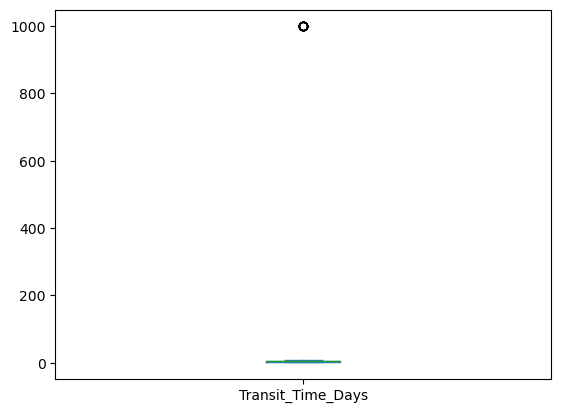

In [41]:
data['Transit_Time_Days'].plot(kind='box')
plt.show()

In [42]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Transit_Time_Days'].quantile(0.25)
Q3 = data['Transit_Time_Days'].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Define the upper boundary line
upper_boundary = Q3 + (1.5 * IQR)

print(f"The middle 50% of deliveries take between {Q1} and {Q3} days.")
print(f"Any delivery taking more than {upper_boundary} days is mathematically an outlier.")



The middle 50% of deliveries take between 2.0 and 6.0 days.
Any delivery taking more than 12.0 days is mathematically an outlier.


In [43]:
data.shape

(1000, 16)

In [44]:
data.loc[
    data["Transit_Time_Days"] > upper_boundary,
    ["Order_ID", "Transit_Time_Days", "Fulfillment_Status", "Courier_Partner"]
]

,Order_ID,Transit_Time_Days,Fulfillment_Status,Courier_Partner
216,KE-10217,999.0,Delivered,DHL
222,KE-10223,999.0,Cancelled,Local Rider
339,KE-10340,999.0,Delayed,Sendy
475,KE-10476,999.0,Returned,DHL
487,KE-10488,999.0,Delivered,Local Rider
600,KE-10601,999.0,Delayed,Local Rider
620,KE-10621,999.0,Delivered,Sendy
651,KE-10652,999.0,Delayed,Chui Lockers
672,KE-10673,999.0,Returned,G4S
757,KE-10758,999.0,Delivered,Wells Fargo


In [45]:
data["Unresolved_Transit_Time"] = data["Transit_Time_Days"].eq(999)

data["Transit_Time_For_Analysis"] = data["Transit_Time_Days"].where(
    ~data["Unresolved_Transit_Time"]
)

In [46]:
data['Transit_Time_Days'].describe()

count    952.000000
mean      16.410714
std      111.096137
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max      999.000000
Name: Transit_Time_Days, dtype: float64

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order_ID                   1000 non-null   object        
 1   Customer_ID                1000 non-null   object        
 2   Order_Date                 964 non-null    datetime64[ns]
 3   Customer_County            972 non-null    object        
 4   Product_Category           1000 non-null   object        
 5   Order_Value_KES            971 non-null    float64       
 6   Payment_Method             966 non-null    object        
 7   Delivery_Method            1000 non-null   object        
 8   Courier_Partner            1000 non-null   object        
 9   Package_Weight_Kg          1000 non-null   object        
 10  Shipping_Fee_KES           1000 non-null   int64         
 11  Transit_Time_Days          952 non-null    float64       
 12  Fulfill

In [48]:
data['Package_Weight_Kg'].value_counts().head(20)

Package_Weight_Kg
35kg     29
26.49     4
34.34     3
3.54      3
16.71     3
29.62     3
5.08      3
3.01      3
33.24     3
12.15     3
19.92     3
12.63     3
5.93      3
25.55     3
10.54     3
27.6      3
1.79      3
16.62     3
30.92     2
32.12     2
Name: count, dtype: int64

In [49]:
data['Package_Weight_Kg'] = (
    data['Package_Weight_Kg']
    .astype(str)
    .str.replace(r'(?i)\s*kg|\s*k', '', regex=True)
    .str.replace(',', '', regex=False)
    .str.strip()
)

data['Package_Weight_Kg'] = pd.to_numeric(
    data['Package_Weight_Kg'], 
    errors='coerce'
)

### Repeated order identifiers
Six IDs appear twice, affecting 12 records. The paired rows have different customers, dates, amounts, and other details. They may represent separate orders with conflicting IDs; source confirmation is needed.

Retained and flagged both rows.

In [50]:
data.loc[
    data.duplicated(subset=["Order_ID"], keep=False)
].sort_values("Order_ID")

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating,Negative_Order_Value,Order_Value_For_Analysis,Unresolved_Transit_Time,Transit_Time_For_Analysis
13,KE-10014,CUST-5135,2025-03-01,Nairobi,Home & Living,11735.0,Cash on Delivery,Home Delivery,Sendy,22.24,0,7.0,Delivered,NaN,False,11735.0,False,7.0
14,KE-10014,CUST-5226,2025-10-10,Nairobi,Beauty,18377.0,Cash on Delivery,Pickup Station,Chui Lockers,4.55,190,2.0,Delivered,5.0,False,18377.0,False,2.0
40,KE-10041,CUST-5436,2025-06-18,Kiambu,Beauty,16489.0,Cash on Delivery,Home Delivery,Chui Lockers,34.24,252,NaN,Delivered,1.0,False,16489.0,False,NaN
41,KE-10041,CUST-5150,2025-07-03,Nakuru,Beauty,6070.0,M-Pesa,Pickup Station,G4S,16.19,411,7.0,Cancelled,2.0,False,6070.0,False,7.0
103,KE-10104,CUST-5459,2025-10-04,Nairobi,Beauty,16909.0,M-Pesa,Smart Locker,Local Rider,26.94,556,3.0,Delayed,4.0,False,16909.0,False,3.0
104,KE-10104,CUST-5116,2025-07-02,Nairobi,Beauty,20770.0,Cash on Delivery,Pickup Station,DHL,13.70,0,3.0,Delivered,2.0,False,20770.0,False,3.0
310,KE-10311,CUST-5154,2025-07-22,Nakuru,Fashion & Apparel,17006.0,M-Pesa,Boda Boda Last-Mile,G4S,9.19,280,7.0,Delayed,3.0,False,17006.0,False,7.0
311,KE-10311,CUST-5462,2025-05-15,Mombasa,Groceries,10839.0,Credit/Debit Card,Boda Boda Last-Mile,Sendy,6.69,0,3.0,Delivered,4.0,False,10839.0,False,3.0
548,KE-10549,CUST-5127,2025-05-24,Nairobi,Beauty,18125.0,M-Pesa,Home Delivery,Wells Fargo,34.20,305,5.0,Delivered,4.0,False,18125.0,False,5.0
549,KE-10549,CUST-5125,2025-06-17,Mombasa,Health & Wellness,1216.0,Cash on Delivery,Smart Locker,Chui Lockers,26.18,478,4.0,Returned,3.0,False,1216.0,False,4.0


In [51]:
data["Repeated_Order_ID"] = data.duplicated(
  subset=["Order_ID"], keep=False
    
)

### Zero shipping fees: hypothesis and stopping decision
There are 54 zero-fee records. Zero-fee shares are similar across delivery methods (approximately 4.8%–5.9%), so method alone does not clearly explain the zeros.

Testing whether zero-fee orders tend to have higher order values. Their usable mean is about KES 13,920 versus KES 12,776 for non-zero-fee orders; their medians are about KES 14,041 and KES 12,800. Only 52 of the 54 zero-fee records have usable amounts.

The ranges overlap: zero-fee values span KES 1,606–24,084, and non-zero-fee values span KES 535–24,953. A higher group average does not establish a spending threshold or prove the zero fees are errors.

**Decision:** retained zero fees unchanged. Their explanation is unconfirmed; further investigation would require policy or promotion information.

In [52]:
pd.crosstab(data['Delivery_Method'],data["Shipping_Fee_KES"].eq(0))


Shipping_Fee_KES,False,True
Delivery_Method,,
Boda Boda Last-Mile,241,15
Home Delivery,237,12
Pickup Station,240,13
Smart Locker,228,14


Do zero-fee orders tend to have higher order values than orders with a shipping fee?

In [53]:
data.loc [
    data["Shipping_Fee_KES"].eq(0),
    ["Shipping_Fee_KES", "Order_Value_For_Analysis"]
]

,Shipping_Fee_KES,Order_Value_For_Analysis
12,0,4840.0
13,0,11735.0
38,0,18585.0
42,0,15469.0
48,0,20029.0
62,0,11697.0
68,0,18391.0
104,0,20770.0
109,0,12281.0
140,0,22455.0


In [54]:
data.groupby(
    data["Shipping_Fee_KES"].eq(0)
)["Order_Value_For_Analysis"].agg(["count", "mean", "median"])

,count,mean,median
Shipping_Fee_KES,,,
False,900,12775.928889,12799.5
True,52,13920.076923,14040.5


In [55]:
data.loc[
    data["Shipping_Fee_KES"].eq(0),
    "Order_Value_For_Analysis"
].agg(["min", "max"])

min     1606.0
max    24084.0
Name: Order_Value_For_Analysis, dtype: float64

free shipping occurs for both relatively low and high order values. The higher average doesn’t mean free shipping is limited to high-value orders.

For example, a rule saying “free shipping only above KES 10,000” would not explain the KES 1,606 order without an exception.

In [56]:
data.groupby(
    data["Shipping_Fee_KES"].eq(0)
)["Order_Value_For_Analysis"].agg(["min", "max"])

,min,max
Shipping_Fee_KES,,
False,535.0,24953.0
True,1606.0,24084.0


### Business Questions

Q1- Geographic Performance
How does e-commerce performance vary across Kenyan counties in terms of order-record volume, recorded order value, and transit time?

Q2 — Courier performance

Which courier partners and delivery methods provide the best balance of delivery speed, fulfillment performance, and customer satisfaction?

Q3 — Delivery economics

How do package weight, shipping fees, and delivery time relate to each other?

Q4 — Customer experience

To what extent is delivery performance associated with customer satisfaction?

### Q1 — Geographic performance: measure definitions
- **Order records:** row count per county, including records with unusable monetary or transit values.
- **Total usable recorded order value:** sum of non-missing, unflagged amounts, including all fulfillment statuses.
- **Average usable order value:** mean of available, unflagged amounts; its denominator can differ from the record count.
- **Average recorded transit time:** mean of available durations excluding unresolved `999` values.

County grouping excludes missing county labels by default: 972 records are assigned to counties and 28 are unassigned. Monetary and transit measures have different usable-record coverage. Repeated IDs remain unresolved. These measures cannot identify one overall best county without an explicit business objective.

In [57]:
county_summary = data.groupby("Customer_County").agg(
    Order_Records=("Order_ID", "size"),
    Total_Order_Value_KES=("Order_Value_For_Analysis", "sum"),
    Average_Transit_Days=("Transit_Time_For_Analysis", "mean")
)

county_summary

,Order_Records,Total_Order_Value_KES,Average_Transit_Days
Customer_County,,,
Kajiado,82,1019897.0,3.480519
Kiambu,170,1986635.0,4.012739
Kisumu,65,832716.0,3.515625
Machakos,85,1005406.0,3.777778
Mombasa,169,2117734.0,3.820513
Nairobi,253,3112741.0,3.890295
Nakuru,71,872803.0,3.855072
Uasin Gishu,77,900144.0,4.405405


Nairobi has the highest number of order records (253) and the highest total usable recorded order value (KES 3,112,741) among counties in the dataset.

could Nairobi’s higher total order value simply be because it has more orders?

In [58]:
data.groupby('Customer_County')['Order_Value_For_Analysis'].mean()

Customer_County
Kajiado        12748.712500
Kiambu         12040.212121
Kisumu         13217.714286
Machakos       12567.575000
Mombasa        13153.627329
Nairobi        12969.754167
Nakuru         13637.546875
Uasin Gishu    12502.000000
Name: Order_Value_For_Analysis, dtype: float64

Nairobi leads in order volume and total recorded order value, while Nakuru has the highest average usable order value.

In [59]:
data.loc[
    data["Customer_County"].eq("Uasin Gishu")
].groupby("Delivery_Method")["Transit_Time_For_Analysis"].agg(
    ["count", "mean"]
)

,count,mean
Delivery_Method,,
Boda Boda Last-Mile,26,4.461538
Home Delivery,19,3.947368
Pickup Station,14,5.642857
Smart Locker,15,3.733333


Within Uasin Gishu, pickup-station orders had the longest average transit time at 5.64 days, compared with 3.73 days for smart-locker orders.

### Q1 — Findings and business interpretation
| Measure | Leading or flagged county | Finding |
|---|---|---|
| Order-record volume | Nairobi | 253 records, the largest county count |
| Total usable recorded order value | Nairobi | KES 3,112,741 |
| Average usable order value | Nakuru | Approximately KES 13,638, versus KES 12,970 in Nairobi |
| Longest average recorded transit time | Uasin Gishu | Approximately 4.41 days |
| Shortest average recorded transit time | Kajiado | Approximately 3.48 days |

Nairobi's larger recorded volume helps explain its leading total value; it does not have the highest average usable value per order. Nakuru's higher average alone does not justify the largest marketing allocation. Profit, acquisition costs, and growth potential are not established here.

Within Uasin Gishu, pickup-station records have the longest average transit time: 5.64 days across 14 usable records, compared with 3.73 days across 15 smart-locker records. This identifies a comparison worth investigating, not proof that the method causes slower delivery. Distance is a possible explanation, but dispatch location and actual distance are unavailable.

**Practical implication:** use geographic volume to understand current recorded demand and investigate Uasin Gishu's pickup-station operations before recommending changes. No causal conclusion or budget allocation is established.

### Learning and next step
Preserve records when only particular values are uncertain; use flags and analysis-specific columns. Check identifiers as well as full-row duplicates. Separate observations, hypotheses, and confirmed corrections. Compare total value with average value and volume. Stop EDA when additional exploration is not needed for the immediate business question.



Q2 — Courier performance

Which courier partners and delivery methods provide the best balance of delivery speed, fulfillment performance, and customer satisfaction?

In [73]:
data.groupby("Courier_Partner")["Transit_Time_For_Analysis"].mean()

Courier_Partner
Chui Lockers    3.861635
DHL             3.840764
G4S             3.969136
Local Rider     3.790850
Sendy           3.900000
Wells Fargo     3.840237
Name: Transit_Time_For_Analysis, dtype: float64

In [69]:
# Group by Courier and Delivery Method
summary = (
    data.groupby(["Courier_Partner", "Delivery_Method"])["Transit_Time_For_Analysis"]
        .agg(["count", "mean"])
        .reset_index()
)

print(summary)


   Courier_Partner      Delivery_Method  count      mean
0     Chui Lockers  Boda Boda Last-Mile     40  3.800000
1     Chui Lockers        Home Delivery     33  3.848485
2     Chui Lockers       Pickup Station     48  3.937500
3     Chui Lockers         Smart Locker     38  3.842105
4              DHL  Boda Boda Last-Mile     33  3.818182
5              DHL        Home Delivery     41  3.682927
6              DHL       Pickup Station     39  4.076923
7              DHL         Smart Locker     44  3.795455
8              G4S  Boda Boda Last-Mile     54  4.074074
9              G4S        Home Delivery     40  3.725000
10             G4S       Pickup Station     37  4.000000
11             G4S         Smart Locker     31  4.064516
12     Local Rider  Boda Boda Last-Mile     40  4.075000
13     Local Rider        Home Delivery     42  3.071429
14     Local Rider       Pickup Station     34  3.794118
15     Local Rider         Smart Locker     37  4.297297
16           Sendy  Boda Boda L

In [85]:
# Counts
counts = pd.crosstab(
    data["Courier_Partner"],
    data["Fulfillment_Status"]
)

# Rates (row percentages)
rates = pd.crosstab(
    data["Courier_Partner"],
    data["Fulfillment_Status"],
    normalize="index"
) * 100

# Combine side by side
summary = counts.join(rates, rsuffix="_rate")
print(summary.round(2))


Fulfillment_Status  Cancelled  Delayed  Delivered  Returned  Cancelled_rate  \
Courier_Partner                                                               
Chui Lockers               32       33         80        28           18.50   
DHL                        31       29         74        31           18.79   
G4S                        26       25         89        33           15.03   
Local Rider                27       39         75        22           16.56   
Sendy                      32       24         71        21           21.62   
Wells Fargo                26       32         96        24           14.61   

Fulfillment_Status  Delayed_rate  Delivered_rate  Returned_rate  
Courier_Partner                                                  
Chui Lockers               19.08           46.24          16.18  
DHL                        17.58           44.85          18.79  
G4S                        14.45           51.45          19.08  
Local Rider                23.93     

In [86]:
data.groupby("Courier_Partner")["Customer_Rating"].agg(
    ["count", "mean"]
)

,count,mean
Courier_Partner,,
Chui Lockers,149,2.926174
DHL,128,3.054688
G4S,150,3.006667
Local Rider,144,3.062500
Sendy,128,2.804688
Wells Fargo,149,2.939597


In [87]:
pd.crosstab(
    [data["Courier_Partner"], data["Delivery_Method"]],
    data["Fulfillment_Status"],
    normalize="index"
) * 100

Fulfillment_Status                   Cancelled    Delayed  Delivered  \
Courier_Partner Delivery_Method                                        
Chui Lockers    Boda Boda Last-Mile  16.279070  25.581395  41.860465   
                Home Delivery        25.641026  10.256410  51.282051   
                Pickup Station       15.686275  21.568627  47.058824   
                Smart Locker         17.500000  17.500000  45.000000   
DHL             Boda Boda Last-Mile  20.588235  14.705882  41.176471   
                Home Delivery        17.777778  20.000000  48.888889   
                Pickup Station       14.634146  24.390244  43.902439   
                Smart Locker         22.222222  11.111111  44.444444   
G4S             Boda Boda Last-Mile  10.344828  17.241379  46.551724   
                Home Delivery        16.666667  19.047619  47.619048   
                Pickup Station       22.500000   7.500000  52.500000   
                Smart Locker         12.121212  12.121212  63.636364   
Local Rider     Boda Boda Last-Mile  20.930233  23.255814  41.860465   
                Home Delivery         9.090909  27.272727  54.545455   
                Pickup Station       27.027027  24.324324  35.135135   
                Smart Locker         10.256410  20.512821  51.282051   
Sendy           Boda Boda Last-Mile  19.047619  23.809524  38.095238   
                Home Delivery        15.384615  12.820513  58.974359   
                Pickup Station       38.888889  13.888889  41.666667   
                Smart Locker         12.903226  12.903226  54.838710   
Wells Fargo     Boda Boda Last-Mile  11.111111  13.888889  52.777778   
                Home Delivery        17.500000  17.500000  47.500000   
                Pickup Station       16.666667  20.833333  54.166667   
                Smart Locker         12.962963  18.518519  59.259259   

Fulfillment_Status                    Returned  
Courier_Partner Delivery_Method                 
Chui Lockers    Boda Boda Last-Mile  16.279070  
                Home Delivery        12.820513  
                Pickup Station       15.686275  
                Smart Locker         20.000000  
DHL             Boda Boda Last-Mile  23.529412  
                Home Delivery        13.333333  
                Pickup Station       17.073171  
                Smart Locker         22.222222  
G4S             Boda Boda Last-Mile  25.862069  
                Home Delivery        16.666667  
                Pickup Station       17.500000  
                Smart Locker         12.121212  
Local Rider     Boda Boda Last-Mile  13.953488  
                Home Delivery         9.090909  
                Pickup Station       13.513514  
                Smart Locker         17.948718  
Sendy           Boda Boda Last-Mile  19.047619  
                Home Delivery        12.820513  
                Pickup Station        5.555556  
                Smart Locker         19.354839  
Wells Fargo     Boda Boda Last-Mile  22.222222  
                Home Delivery        17.500000  
                Pickup Station        8.333333  
                Smart Locker          9.259259

In [88]:
data.loc[
    data["Delivery_Method"].eq("Smart Locker")
    & data["Courier_Partner"].isin(["G4S", "Wells Fargo"])
].groupby("Courier_Partner")["Customer_Rating"].agg(["count", "mean"])

,count,mean
Courier_Partner,,
G4S,29,2.758621
Wells Fargo,44,2.772727


In [89]:
comparison = data.groupby(
    ["Courier_Partner", "Delivery_Method"]
).agg(
    Order_Records=("Order_ID", "size"),
    Transit_Count=("Transit_Time_For_Analysis", "count"),
    Average_Transit_Days=("Transit_Time_For_Analysis", "mean"),
    Delivered_Share_Pct=(
        "Fulfillment_Status",
        lambda statuses: statuses.eq("Delivered").mean() * 100
    ),
    Rating_Count=("Customer_Rating", "count"),
    Average_Rating=("Customer_Rating", "mean")
)

comparison.round(2)

Order_Records  Transit_Count  \
Courier_Partner Delivery_Method                                     
Chui Lockers    Boda Boda Last-Mile             43             40   
                Home Delivery                   39             33   
                Pickup Station                  51             48   
                Smart Locker                    40             38   
DHL             Boda Boda Last-Mile             34             33   
                Home Delivery                   45             41   
                Pickup Station                  41             39   
                Smart Locker                    45             44   
G4S             Boda Boda Last-Mile             58             54   
                Home Delivery                   42             40   
                Pickup Station                  40             37   
                Smart Locker                    33             31   
Local Rider     Boda Boda Last-Mile             43             40   
                Home Delivery                   44             42   
                Pickup Station                  37             34   
                Smart Locker                    39             37   
Sendy           Boda Boda Last-Mile             42             40   
                Home Delivery                   39             37   
                Pickup Station                  36             34   
                Smart Locker                    31             29   
Wells Fargo     Boda Boda Last-Mile             36             34   
                Home Delivery                   40             38   
                Pickup Station                  48             44   
                Smart Locker                    54             53   

                                     Average_Transit_Days  \
Courier_Partner Delivery_Method                             
Chui Lockers    Boda Boda Last-Mile                  3.80   
                Home Delivery                        3.85   
                Pickup Station                       3.94   
                Smart Locker                         3.84   
DHL             Boda Boda Last-Mile                  3.82   
                Home Delivery                        3.68   
                Pickup Station                       4.08   
                Smart Locker                         3.80   
G4S             Boda Boda Last-Mile                  4.07   
                Home Delivery                        3.72   
                Pickup Station                       4.00   
                Smart Locker                         4.06   
Local Rider     Boda Boda Last-Mile                  4.08   
                Home Delivery                        3.07   
                Pickup Station                       3.79   
                Smart Locker                         4.30   
Sendy           Boda Boda Last-Mile                  4.10   
                Home Delivery                        3.86   
                Pickup Station                       3.79   
                Smart Locker                         3.79   
Wells Fargo     Boda Boda Last-Mile                  3.91   
                Home Delivery                        3.74   
                Pickup Station                       4.05   
                Smart Locker                         3.70   

                                     Delivered_Share_Pct  Rating_Count  \
Courier_Partner Delivery_Method                                          
Chui Lockers    Boda Boda Last-Mile                41.86            35   
                Home Delivery                      51.28            36   
                Pickup Station                     47.06            41   
                Smart Locker                       45.00            37   
DHL             Boda Boda Last-Mile                41.18            27   
                Home Delivery                      48.89            35   
                Pickup Station                     43.90       

## Q2 — Courier and Delivery-Method Performance

Which courier partners and delivery methods provide the best balance of delivery speed, fulfillment performance, and customer satisfaction?

### 1. Select Measures
Three measures were used:

- **Average recorded transit time:** lower values indicate shorter recorded durations.
- **Delivered share:** the percentage of a group's records marked Delivered.
- **Average customer rating:** higher values indicate more positive feedback among customers who provided ratings.

Record counts and usable-value counts were included to show how much data supports each comparison.

### 2. Compare Recorded Transit Times by Courier
Average transit time was calculated for each courier using `Transit_Time_For_Analysis`.

This column excludes missing times and the 12 unresolved values of `999`, while retaining the orders in the dataset.

Local Rider had the shortest courier-wide average at approximately 3.79 days. Courier-wide averages were relatively close, ranging from approximately 3.79 to 3.97 days.

These are recorded transit times across all fulfillment statuses, rather than verified completed-delivery durations.

### 3. Compare Transit Times by Courier and Delivery Method
Records were grouped by both courier and delivery method, calculating the count and mean of usable transit times.

This revealed differences hidden by courier-wide averages. For example, Local Rider averaged 3.07 days for Home Delivery but 4.30 days for Smart Locker.

Therefore, courier-wide performance alone was insufficient for selecting a courier for a particular method.

### 4. Compare Fulfillment Outcomes
A cross-tabulation counted Delivered, Delayed, Cancelled, and Returned records for each courier.

Row percentages were also calculated because couriers handled different numbers of records. Counts describe workload; percentages describe how common each outcome was within a courier's records.

Wells Fargo had the highest delivered share at 53.93% and the lowest cancellation share at 14.61%.

These outcomes are associated with the couriers in this dataset. They do not establish that couriers caused cancellations, delays, or returns.

### 5. Compare Customer Ratings
The available rating count and average rating were calculated for each courier.

Local Rider and DHL had very similar leading averages of approximately 3.06. Wells Fargo averaged approximately 2.94.

Missing ratings were excluded from the means. These averages represent available feedback, not every customer's experience.

### 6. Examine Courier–Method Fulfillment and Ratings
Fulfillment percentages were calculated separately for each courier–method combination.

This showed that the overall leader did not lead every method. For Smart Locker, G4S had a higher delivered share than Wells Fargo: 63.64% versus 59.26%.

Their Smart Locker ratings were also compared. They were very similar: approximately 2.76 for G4S and 2.77 for Wells Fargo. Wells Fargo had the shorter average recorded transit time: 3.70 versus 4.06 days.

### 7. Build a Combined Comparison Table
Each courier–method combination was summarized using:

- Total order-record count.
- Usable transit-time count and average recorded transit time.
- Delivered share.
- Available rating count and average customer rating.

The three measures were compared together without creating a weighted score, because business priorities and weights had not been established.

### 8. Interpret Tradeoffs

#### Overall Courier Comparison
Wells Fargo was provisionally favored when fulfillment was prioritized. It combined the highest delivered share, lowest cancellation share, and a competitive recorded transit time.

Its tradeoff was a lower average customer rating than Local Rider and DHL.

#### Home Delivery
Local Rider was shortlisted as a balanced candidate:

- Shortest average recorded transit time: 3.07 days.
- Delivered share: 54.55%.
- Average rating: 3.20.

Sendy had a higher delivered share at 58.97%, while Wells Fargo had a higher average rating at 3.31. Local Rider did not lead every measure.

#### Boda Boda Last-Mile
Wells Fargo was provisionally shortlisted when fulfillment was prioritized:

- Highest delivered share: 52.78%.
- Average recorded transit time: 3.91 days.
- Average rating: 2.97.

Chui Lockers had a shorter recorded time of 3.80 days, while G4S had a slightly higher rating of 3.02.

#### Smart Locker
No single preferred option was established:

- G4S led on delivered share.
- Wells Fargo had shorter recorded transit time.
- Their ratings were very similar.
- Sendy had the highest average rating among Smart Locker combinations, at 3.23, illustrating another tradeoff.

Pickup Station results were included in the combined table, but a final shortlist was not established.

### Conclusion
No courier leads on every measure across every delivery method. Selection should consider the specific method and the company's priorities.

Wells Fargo is a provisional overall choice when fulfillment is prioritized. Local Rider is a balanced Home Delivery candidate, while Wells Fargo is a Boda Boda Last-Mile candidate.

These are exploratory shortlists, not confirmed operational recommendations.

### Limitations
- Transit times include multiple fulfillment statuses.
- Transit-time and rating averages use different subsets of available records.
- Repeated order IDs remain unresolved.
- Delivered share is a status proportion, not an on-time delivery rate.
- County and route differences were not controlled for.
- Small differences in averages were not tested for statistical significance.

### What I Learned
Overall averages can hide differences within delivery methods. Fair comparisons need percentages alongside counts, and recommendations should explain tradeoffs rather than selecting a winner from one measure.